# Model accuracy against the adjudicated gold labels

`data/adjudicated-all-rounds.csv` is the gold standard: justifications coded by humans and
then resolved into one agreed set of codes per row. This notebook scores a language model
against those labels.

The gold units are split in half. Few-shot examples come only from **train**. Every score
below is on the held-out **test** half.

Coding is row-level: each justification gets a set of codes from `data/codebook.csv`.

| metric | meaning |
|---|---|
| `micro_f1` | overall precision/recall across all code assignments |
| `macro_f1_present_codes` | mean F1 over codes that appear in the gold |
| `exact_set_match` | units whose predicted code set matches the gold set exactly |
| `mean_jaccard` | average overlap between predicted and gold code sets |

In [18]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# Drop a stale in-memory copy of the package (from before the gold-only loader).
for _name in list(sys.modules):
    if _name == "thematic_ai" or _name.startswith("thematic_ai."):
        del sys.modules[_name]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from thematic_ai import RunConfig, annotate_units, evaluate_run, get_backend
from thematic_ai.pipeline import load_workspace, make_context_builder, make_system_prompt

pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 80)

EVAL_DIR = PROJECT_ROOT / "outputs" / "evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

## 1. Gold labels and train/test split

The split is stratified on how many codes a unit carries so both halves have the same mix.

In [19]:
ws = load_workspace(RunConfig(), test_size=0.5)

print(
    f"{len(ws.gold)} adjudicated units  |  "
    f"train {len(ws.train)}  |  test {len(ws.test)}  |  "
    f"{int(ws.gold['n_gold_codes'].sum())} gold code assignments"
)

split_summary = pd.DataFrame(
    {
        "train": ws.train["n_gold_codes"].value_counts().sort_index(),
        "test": ws.test["n_gold_codes"].value_counts().sort_index(),
    }
).fillna(0).astype(int)
split_summary.index.name = "codes per unit"
display(split_summary)
display(ws.gold[["unit_text", "gold_codes"]].head(6))

376 adjudicated units  |  train 189  |  test 187  |  655 gold code assignments


,train,test
codes per unit,,
0,1,0
1,86,86
2,71,71
3,25,26
4,4,3
5,1,0
6,1,0
7,0,1


,unit_text,gold_codes
0,The account should be suspended. Every comment is offensive.,"[Consistent offensive behavior, Extreme offensive]"
1,Every comment was offensive. The account should be suspended.,[Consistent offensive behavior]
2,None of the comments were offensive. There was no reason to suspend.,[No offensive content]
3,This appears to be a classic hate-filled troll account. 100% of the 3 messa...,"[Consistent offensive behavior, Troll or bot]"
4,None of the messages I read from this account included anything that could b...,[No offensive content]
5,Threatening physical harm is grounds to suspend someone in my book.,[Threats of violence]


## 2. Code the test half

Answers are cached under `outputs/cache/`, so re-running this cell does not re-call the model.

In [20]:
BACKEND = "openai"      # "openai" | "ollama"
MODEL = "gpt-5.1"
VARIANTS = ("codebook_only", "few_shot", "calibrated")
TEST_LIMIT = 0          # 0 = the whole test half

RESULTS = {}
test_units = ws.test.head(TEST_LIMIT) if TEST_LIMIT else ws.test

for variant in VARIANTS:
    config = RunConfig(
        backend=BACKEND,
        model=MODEL,
        prompt_variant=variant,
        run_label="test_split",
    )
    backend = get_backend(config)
    print(f"\n{config.backend}:{config.model} | {variant} | {len(test_units)} units")

    run = annotate_units(
        test_units,
        ws.codebook,
        config,
        make_system_prompt(ws, config),
        backend=backend,
        context_builder=make_context_builder(ws, config),
        progress=lambda done, total: print(f"  {done}/{total}", end="\r"),
    )
    run.save(PROJECT_ROOT / "outputs", prefix="eval")
    result = evaluate_run(run, ws.gold_labels, ws.codebook)
    RESULTS[variant] = {"run": run, "result": result, "config": config}

    print(
        f"\n  micro-F1 {result.overall['micro_f1']:.3f}  |  "
        f"exact-set {result.overall['exact_set_match']:.3f}  |  "
        f"{run.n_failed} failed"
    )


openai:gpt-5.1 | codebook_only | 187 units
  187/187
  micro-F1 0.572  |  exact-set 0.171  |  1 failed

openai:gpt-5.1 | few_shot | 187 units
  187/187
  micro-F1 0.594  |  exact-set 0.209  |  1 failed

openai:gpt-5.1 | calibrated | 187 units
  187/187
  micro-F1 0.697  |  exact-set 0.390  |  1 failed


## 3. Overall accuracy vs gold

`gold_labels` vs `pred_labels` is the first thing to read: applying far more codes than the
humans did is high recall and low precision.

,prompt_variant,n_units,gold_labels,pred_labels,micro_precision,micro_recall,micro_f1,macro_f1_present_codes,exact_set_match,mean_jaccard
0,codebook_only,187,325,574,0.448,0.791,0.572,0.519,0.171,0.466
1,few_shot,187,325,527,0.480,0.778,0.594,0.561,0.209,0.495
2,calibrated,187,325,329,0.693,0.702,0.697,0.571,0.390,0.614


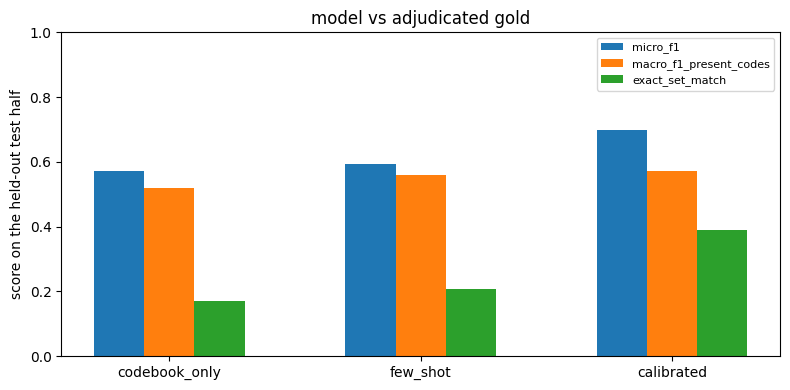

In [22]:
summary = pd.DataFrame(
    [
        {
            "prompt_variant": variant,
            "model": f"{entry['config'].backend}:{entry['config'].model}",
            **entry["result"].overall,
        }
        for variant, entry in RESULTS.items()
    ]
)
cols = [
    "prompt_variant", "n_units", "gold_labels", "pred_labels",
    "micro_precision", "micro_recall", "micro_f1",
    "macro_f1_present_codes", "exact_set_match", "mean_jaccard",
]
display(summary[cols].round(3))
summary.to_csv(EVAL_DIR / "summary__notebook.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(summary))
for offset, metric in [(-0.2, "micro_f1"), (0.0, "macro_f1_present_codes"), (0.2, "exact_set_match")]:
    ax.bar(x + offset, summary[metric], width=0.2, label=metric)
ax.set_xticks(x, summary["prompt_variant"])
ax.set_ylim(0, 1)
ax.set_ylabel("score on the held-out test half")
ax.set_title("model vs adjudicated gold")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 4. Per-code and per-theme

Change `VARIANT` to inspect another prompt. Codes with one or two gold occurrences have noisy F1.

In [23]:
VARIANT = "calibrated"
result = RESULTS[VARIANT]["result"]

per_code = result.per_code[result.per_code["support_gold"] > 0]
display(
    per_code[["code", "support_gold", "support_pred", "precision", "recall", "f1"]]
    .round(3)
)

display(
    result.per_theme[result.per_theme["support_gold"] > 0]
    [["theme", "support_gold", "precision", "recall", "f1"]]
    .round(3)
)

,code,support_gold,support_pred,precision,recall,f1
0,Hate speech and offensive language,75,75,0.840,0.840,0.840
1,Threats of violence,57,59,0.881,0.912,0.897
2,Consistent offensive behavior,34,26,0.692,0.529,0.600
3,No offensive content,31,36,0.750,0.871,0.806
4,Death wish,24,18,0.778,0.583,0.667
5,Majority offesnive,15,11,1.000,0.733,0.846
6,Normal behavior,9,5,0.600,0.333,0.429
7,Harm other person,9,6,0.500,0.333,0.400
8,Calm and thoughtful,7,1,1.000,0.143,0.250
9,Expressed uncertainty,5,4,1.000,0.800,0.889


,theme,support_gold,precision,recall,f1
0,Type of offensiveness,149,0.919,0.913,0.916
1,Patterns of behavior,61,0.789,0.738,0.763
2,Justifications,14,0.611,0.786,0.688
3,Decision outcomes,10,0.571,0.400,0.471
4,Reflection on the decision,10,0.350,0.700,0.467
5,Positive content,10,1.000,0.300,0.462
6,Uncategorised,5,0.300,0.600,0.400


## 5. Units the model got wrong

`missed` is a gold code the model left out. `spurious` is a code the model added that the gold does not have.

In [24]:
errors = result.errors
print(f"{len(errors)} of {result.overall['n_units']} test units differ from gold")
display(errors[["unit_text", "gold_codes", "pred_codes", "missed", "spurious"]].head(20))

114 of 187 test units differ from gold


,unit_text,gold_codes,pred_codes,missed,spurious
0,The account should be suspended. Every comment is offensive.,Consistent offensive behavior; Extreme offensive,Consistent offensive behavior,Extreme offensive,
1,Threatening physical harm is grounds to suspend someone in my book.,Threats of violence,Harm other person; Threats of violence,,Harm other person
2,The multiple death threats and attacking language aren't permitted for onlin...,Harm other person; Majority offesnive; Threats of violence,Hate speech and offensive language; Majority offesnive; Threats of violence,Harm other person,Hate speech and offensive language
3,They never said anything offensive and seemed normal,No offensive content,No offensive content; Normal behavior,,Normal behavior
4,They never said awful stuff and seem decent,No offensive content,No offensive content; positive content,,positive content
5,"There was only one offensive message, and while extreme, I think suspension ...",Not too offensive; One-off offensive,One-off offensive,Not too offensive,
6,"Even though there are some very calm and eloquent messages, there are still ...",Calm and thoughtful; Hate speech and offensive language,Hate speech and offensive language; Mix of offensive and non-offensive; unju...,Calm and thoughtful,Mix of offensive and non-offensive; unjustifiable
7,I dont have enough info about the context for suspension,Contextual understanding; Expressed uncertainty,Contextual understanding,Expressed uncertainty,
8,Account 5 contains nothing but hurtful and suicidal comments that have only ...,Consistent offensive behavior; Death wish,Death wish; Harm other person; Hate speech and offensive language,Consistent offensive behavior,Harm other person; Hate speech and offensive language
9,Account 1 has a history of insulting others with profanity and vulgar slurs....,Consistent offensive behavior; Hate speech and offensive language,Consistent offensive behavior; Hate speech and offensive language; bullying;...,,bullying; insult
